<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Project3/specimens_toy_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Data & Libraries

In [1]:
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3

Cloning into 'Cedars'...
remote: Enumerating objects: 1369, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 1369 (delta 67), reused 4 (delta 4), pack-reused 1257 (from 3)
Receiving objects: 100% (1369/1369), 1.24 GiB | 39.31 MiB/s, done.
Resolving deltas: 100% (547/547), done.
Updating files: 100% (902/902), done.
/content/Cedars/Project3


In [8]:
from matplotlib import pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns

In [3]:
data = pd.read_pickle('specimens_toy_data.pkl')

print(f"Type of Data is {type(data)}")
print(f"Length of Data is {len(data)}")
print(f"Keys in Dictionary: {list(data.keys())}")
print(f"Keys in data['neg']: {list(data['neg'].keys())}")


Type of Data is <class 'dict'>
Length of Data is 4
Keys in Dictionary: ['neg', 'pos', 'aty', 'sus']
Keys in data['neg']: ['imgs', 'metadata']


In [4]:
print(data['neg']['imgs'][3].shape)
i = 3



(37, 35, 3)


#Images

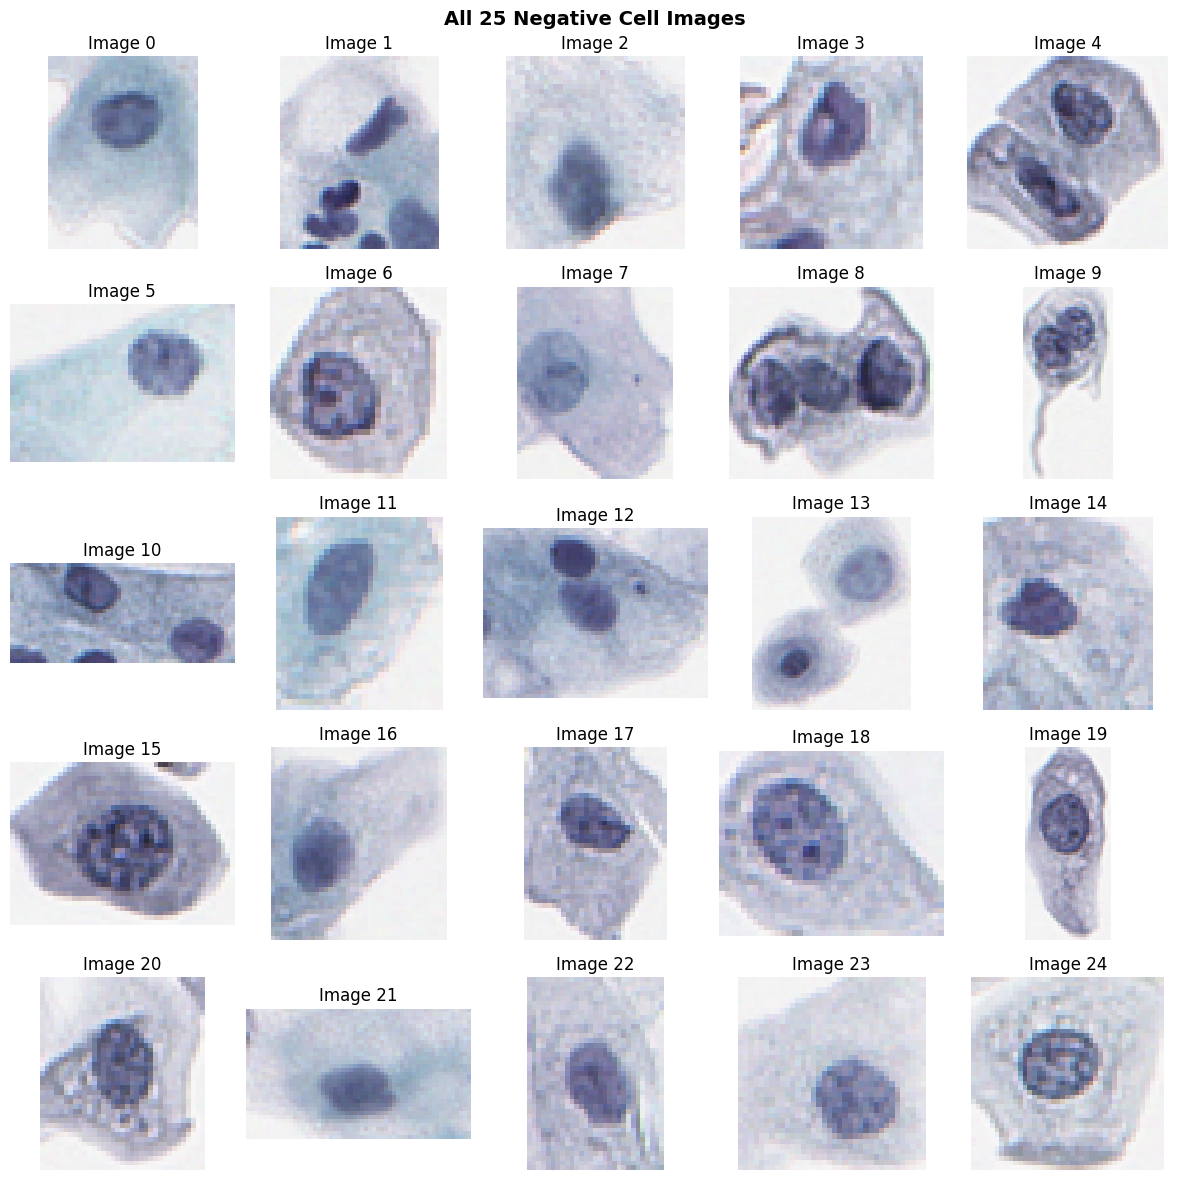

In [31]:
fig, axes = plt.subplots(5, 5, figsize = (12,12))
axes = axes.flatten()

for i, image in enumerate(data['neg']['imgs']):
  axes[i].imshow(image, interpolation='nearest')
  axes[i].set_title(f"Image {i}")
  axes[i].axis('off')

plt.suptitle("All 25 Negative Cell Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

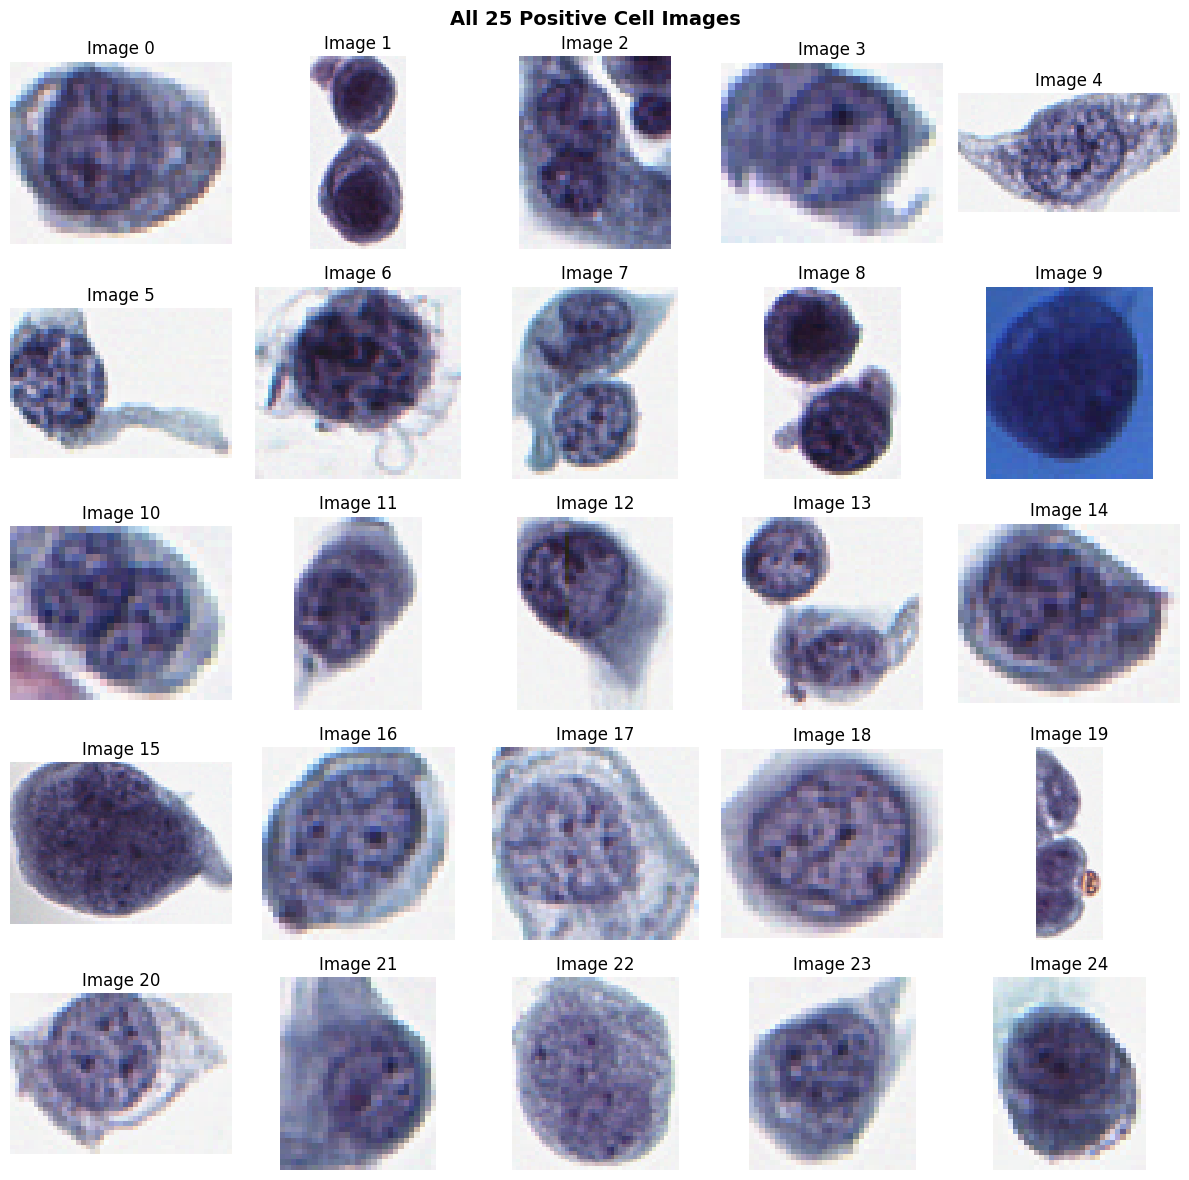

In [32]:
fig, axes = plt.subplots(5, 5, figsize = (12,12))
axes = axes.flatten()

for i, image in enumerate(data['pos']['imgs']):
  axes[i].imshow(image, interpolation='nearest')
  axes[i].set_title(f"Image {i}")
  axes[i].axis('off')

plt.suptitle("All 25 Positive Cell Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

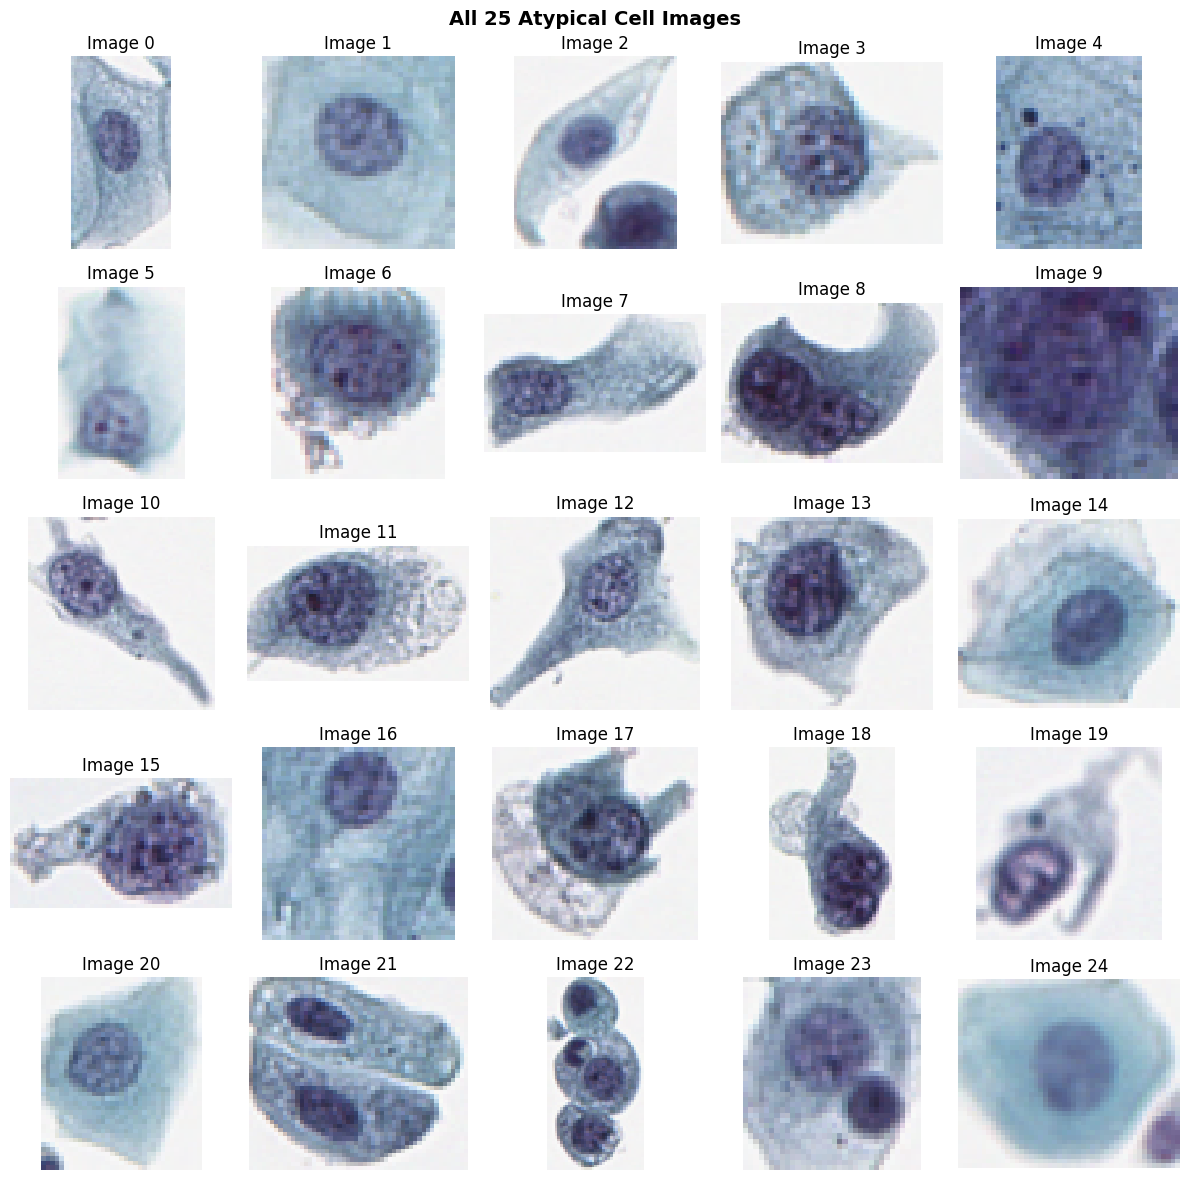

In [33]:
fig, axes = plt.subplots(5, 5, figsize = (12,12))
axes = axes.flatten()

for i, image in enumerate(data['aty']['imgs']):
  axes[i].imshow(image, interpolation='nearest')
  axes[i].set_title(f"Image {i}")
  axes[i].axis('off')

plt.suptitle("All 25 Atypical Cell Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

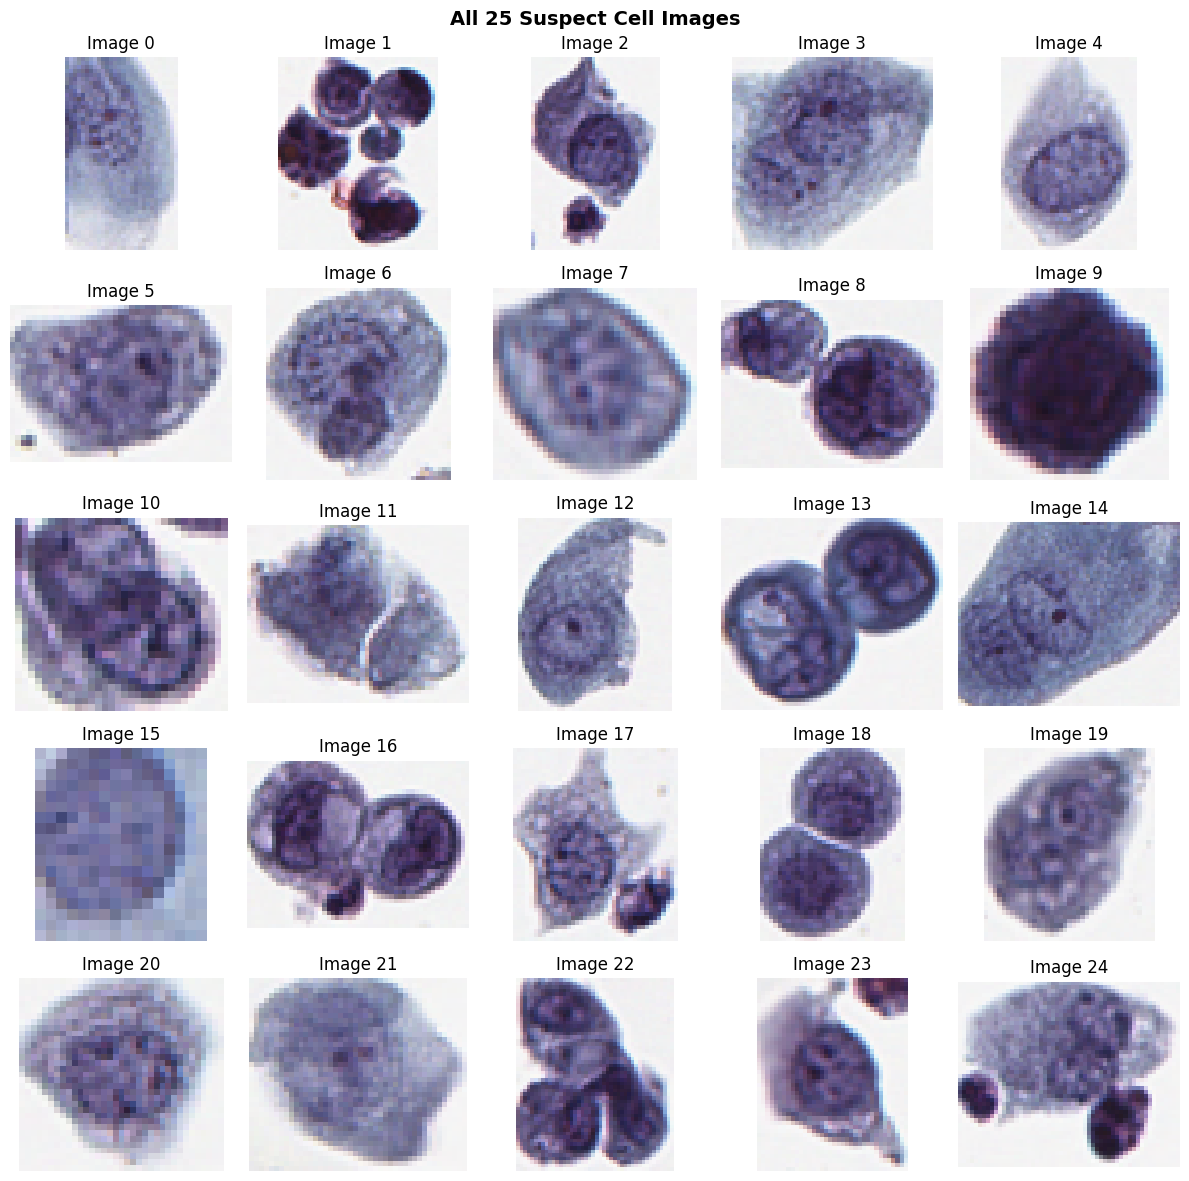

In [34]:
fig, axes = plt.subplots(5, 5, figsize = (12,12))
axes = axes.flatten()

for i, image in enumerate(data['sus']['imgs']):
  axes[i].imshow(image, interpolation='nearest')
  axes[i].set_title(f"Image {i}")
  axes[i].axis('off')

plt.suptitle("All 25 Suspect Cell Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Pandas Dataframe of Metadata from Dictionary

In [5]:
print(data['sus']['metadata'])

         aty  nc_ratio  nuclear_area  cyto_area
0   0.080481  0.309635       16981.0    37861.0
1   0.971470  0.361119       15245.0    26971.0
2   0.323418  0.325203       12400.0    25730.0
3   0.081589  0.379627       19763.0    32296.0
4   0.079329  0.383288       17284.0    27810.0
5   0.102967  0.389471       19657.0    30814.0
6   0.119824  0.432054       20504.0    26953.0
7   0.173267  0.312585       15844.0    34843.0
8   0.730629  0.500874       19764.0    19695.0
9   0.996979  0.703793       36593.0    15401.0
10  0.168216  0.444910       24224.0    30223.0
11  0.104915  0.410302       17883.0    25702.0
12  0.117620  0.321872       13517.0    28478.0
13  0.712443  0.407844       16950.0    24610.0
14  0.064426  0.301378       15458.0    35833.0
15  0.340039  0.625841       36551.0    21852.0
16  0.354943  0.317422       14683.0    31574.0
17  0.222754  0.313877       12906.0    28212.0
18  0.213976  0.477532       22965.0    25126.0
19  0.080178  0.410116       18958.0    

In [6]:
all_metadata=[]
all_labels=[]

for category in ['neg','pos','aty','sus']:
  metadata = data[category]['metadata']
  all_metadata.append(metadata)
  all_labels.extend([category]*len(metadata))

df = pd.concat(all_metadata, ignore_index = True)
df['target']=all_labels
print (df.head())

        aty  nc_ratio  nuclear_area  cyto_area target
0  0.057022  0.141928        7221.0    43657.0    neg
1  0.037513  0.175625        7597.0    35660.0    neg
2  0.056971  0.150782        7442.0    41914.0    neg
3  0.077020  0.182437        8177.0    36644.0    neg
4  0.111039  0.183712        8696.0    38639.0    neg


#Randomize Dataframe & Train-Test Split

In [7]:
 # Shuffle the DataFrame (randomize order)
df_shuffled = df.sample(frac=1, random_state=35).reset_index(drop=True)

print("After shuffling:")
print(df_shuffled.head(10))

After shuffling:
        aty  nc_ratio  nuclear_area  cyto_area target
0  0.756269  0.640938       31115.0    17431.0    pos
1  0.080822  0.154403        7844.0    42958.0    aty
2  0.498367  0.386391       15150.0    24059.0    sus
3  0.681638  0.432516       20253.0    26573.0    pos
4  0.043333  0.197442        9416.0    38274.0    aty
5  0.982240  0.523197       21370.0    19475.0    pos
6  0.074549  0.218542       10808.0    38647.0    neg
7  0.042224  0.151080        8082.0    45413.0    neg
8  0.058979  0.202168       10818.0    42692.0    aty
9  0.372444  0.542887       28298.0    23827.0    pos


#Confusion Matrix

                   aty  nc_ratio  nuclear_area  cyto_area
aty           1.000000  0.576845      0.511641  -0.527519
nc_ratio      0.576845  1.000000      0.960601  -0.825265
nuclear_area  0.511641  0.960601      1.000000  -0.663669
cyto_area    -0.527519 -0.825265     -0.663669   1.000000


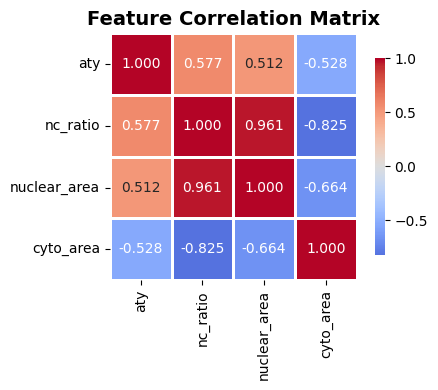

In [13]:
corr = df.select_dtypes(include="number").corr()

print(corr)

# Visualize with heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

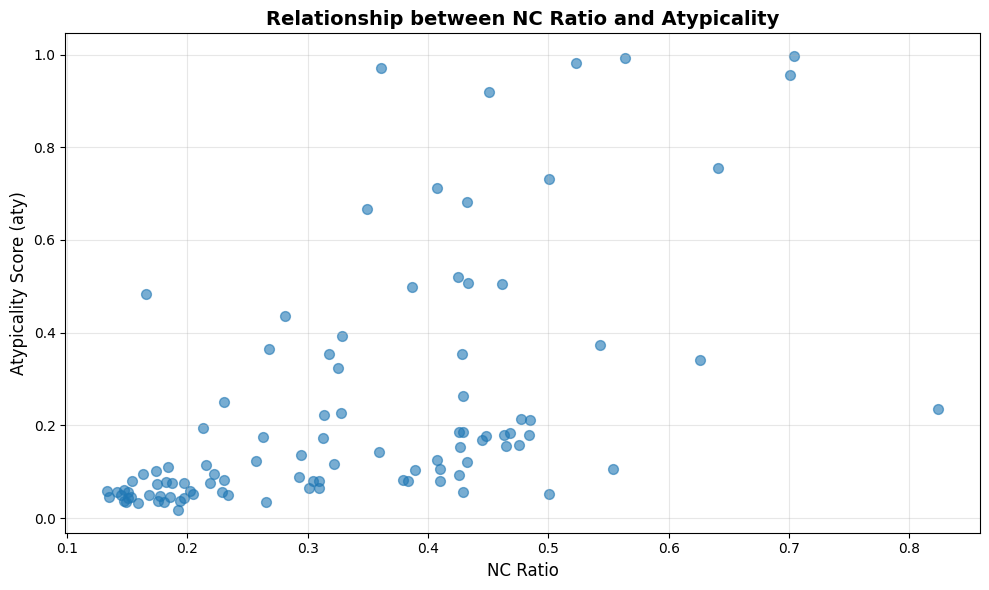

In [14]:
# Basic scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['nc_ratio'], df['aty'], alpha=0.6, s=50)
plt.xlabel('NC Ratio', fontsize=12)
plt.ylabel('Atypicality Score (aty)', fontsize=12)
plt.title('Relationship between NC Ratio and Atypicality', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import pearsonr

# Pearson correlation (measures LINEAR relationship)
pearson_corr, pearson_p = pearsonr(df['nc_ratio'], df['aty'])

print("="*60)
print("CORRELATION TESTS")
print("="*60)
print(f"\nPearson Correlation (linear):")
print(f"  r = {pearson_corr:.4f}")
print(f"  p-value = {pearson_p:.4e}")
if pearson_p < 0.05:
    print(f"  ✓ Statistically significant (p < 0.05)")
else:
    print(f"  ✗ Not statistically significant (p ≥ 0.05)")

CORRELATION TESTS

Pearson Correlation (linear):
  r = 0.5768
  p-value = 3.3572e-10
  ✓ Statistically significant (p < 0.05)


In [16]:
from scipy.stats import spearmanr

# Spearman correlation (measures MONOTONIC relationship, including non-linear)
spearman_corr, spearman_p = spearmanr(df['nc_ratio'], df['aty'])

print(f"\nSpearman Correlation (monotonic, can be non-linear):")
print(f"  ρ = {spearman_corr:.4f}")
print(f"  p-value = {spearman_p:.4e}")
if spearman_p < 0.05:
    print(f"  ✓ Statistically significant (p < 0.05)")
else:
    print(f"  ✗ Not statistically significant (p ≥ 0.05)")

# Compare Pearson vs Spearman
print(f"\nComparison:")
if abs(spearman_corr - pearson_corr) < 0.1:
    print(f"  → Pearson ≈ Spearman: Relationship is likely LINEAR")
else:
    print(f"  → Pearson ≠ Spearman: Relationship may be NON-LINEAR")


Spearman Correlation (monotonic, can be non-linear):
  ρ = 0.6993
  p-value = 5.8237e-16
  ✓ Statistically significant (p < 0.05)

Comparison:
  → Pearson ≠ Spearman: Relationship may be NON-LINEAR


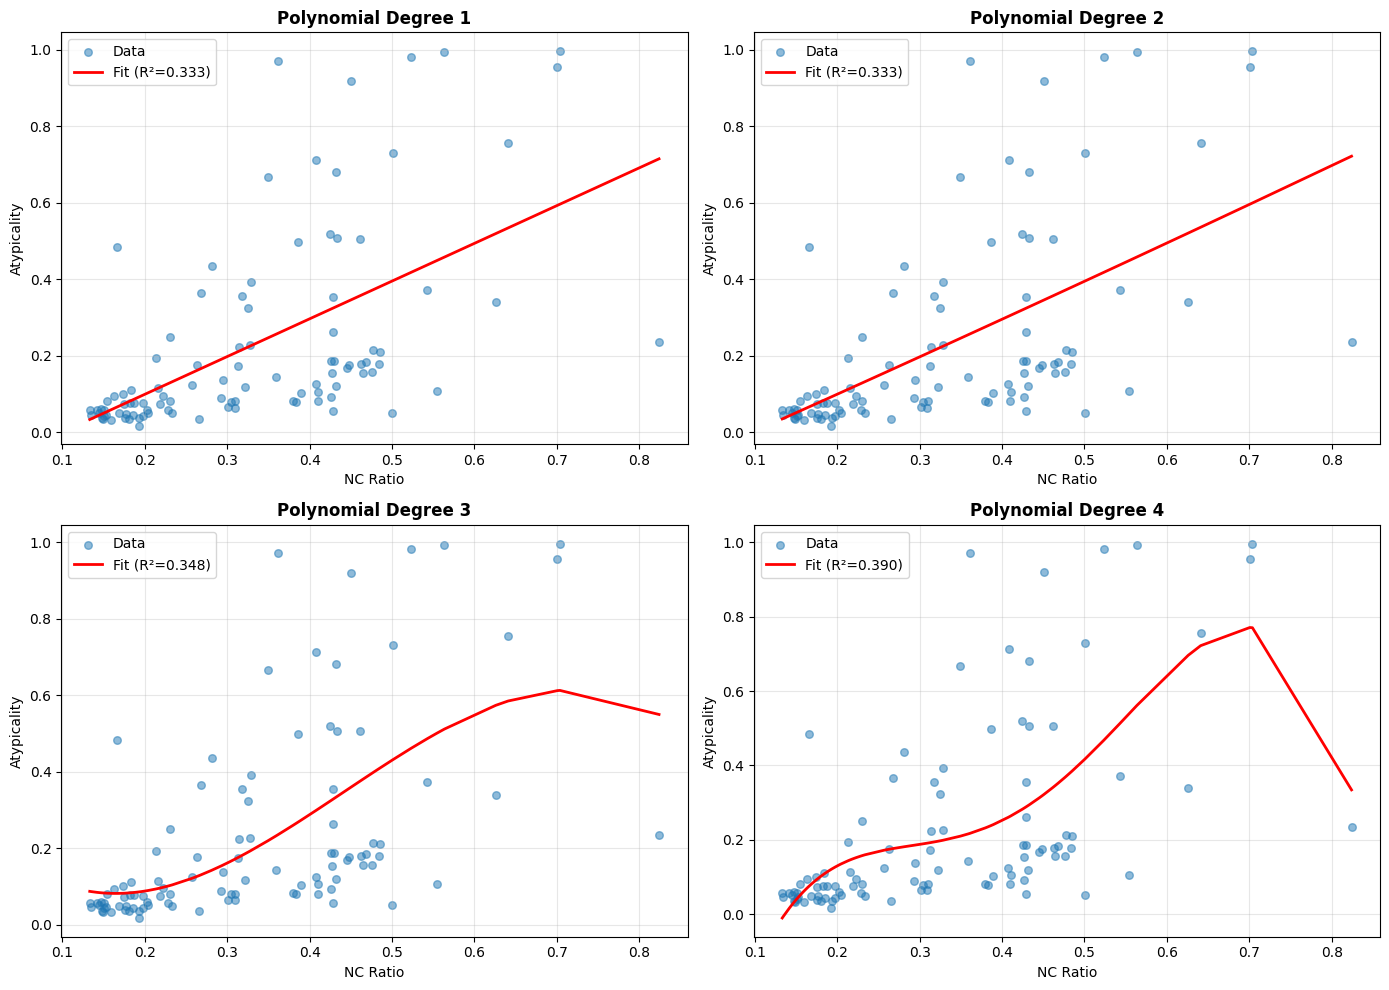


POLYNOMIAL FIT COMPARISON
Degree     R² Score   Interpretation
------------------------------------------------------------
1          0.3328     
2          0.3328     
3          0.3481     
4          0.3895     Best fit!


In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data
X = df['nc_ratio'].values.reshape(-1, 1)
y = df['aty'].values

# Test different polynomial degrees
degrees = [1, 2, 3, 4]
results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, degree in enumerate(degrees):
    # Fit polynomial
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    r2 = r2_score(y, y_pred)

    results.append({'degree': degree, 'r2': r2})

    # Plot
    # Sort for smooth curve
    sort_idx = np.argsort(X.flatten())
    X_sorted = X[sort_idx]
    y_pred_sorted = y_pred[sort_idx]

    axes[i].scatter(X, y, alpha=0.5, s=30, label='Data')
    axes[i].plot(X_sorted, y_pred_sorted, 'r-', linewidth=2, label=f'Fit (R²={r2:.3f})')
    axes[i].set_xlabel('NC Ratio')
    axes[i].set_ylabel('Atypicality')
    axes[i].set_title(f'Polynomial Degree {degree}', fontweight='bold')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('polynomial_fits.png', dpi=150)
plt.show()

# Print results
print("\n" + "="*60)
print("POLYNOMIAL FIT COMPARISON")
print("="*60)
print(f"{'Degree':<10} {'R² Score':<10} {'Interpretation'}")
print("-"*60)
for res in results:
    interp = "Best fit!" if res['r2'] == max([r['r2'] for r in results]) else ""
    print(f"{res['degree']:<10} {res['r2']:<10.4f} {interp}")

#Atypicality by NC Ratio Bins

/tmp/ipython-input-1071627838.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('nc_ratio_bin')['aty'].agg(['mean', 'std', 'count'])



BINNED ANALYSIS
                    mean       std  count
nc_ratio_bin                             
(0.133, 0.271]  0.088691  0.089552     42
(0.271, 0.41]   0.267025  0.245963     23
(0.41, 0.548]   0.303193  0.257175     28
(0.548, 0.686]  0.549056  0.400198      4
(0.686, 0.824]  0.729503  0.428623      3


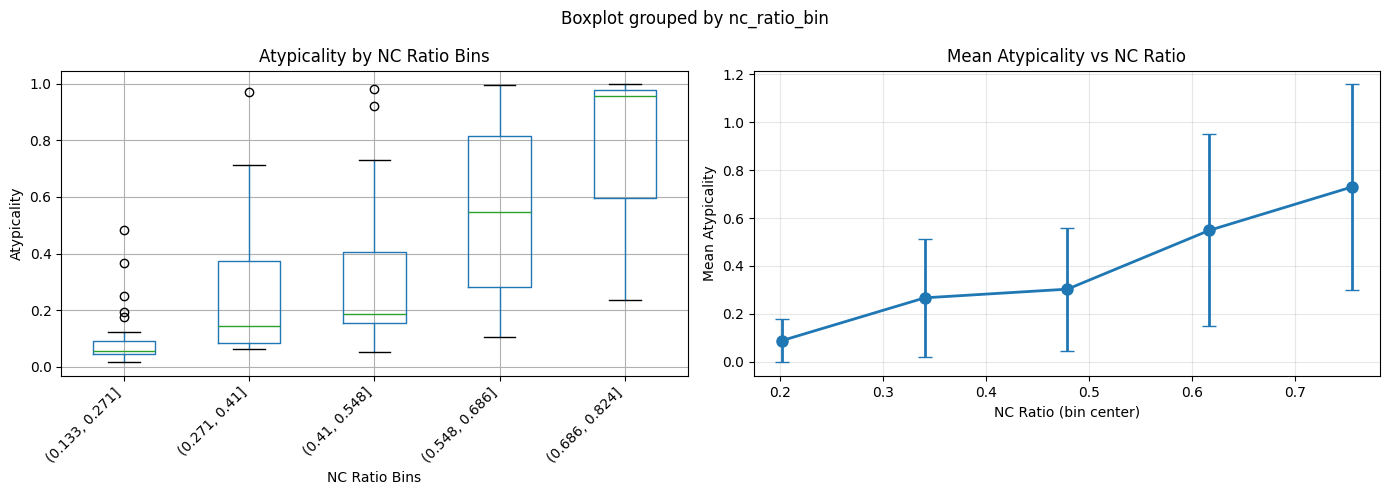

In [18]:
# Bin nc_ratio into groups and see how aty changes
df['nc_ratio_bin'] = pd.cut(df['nc_ratio'], bins=5)

# Calculate mean aty for each bin
binned_stats = df.groupby('nc_ratio_bin')['aty'].agg(['mean', 'std', 'count'])
print("\n" + "="*60)
print("BINNED ANALYSIS")
print("="*60)
print(binned_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='aty', by='nc_ratio_bin', ax=axes[0])
axes[0].set_xlabel('NC Ratio Bins')
axes[0].set_ylabel('Atypicality')
axes[0].set_title('Atypicality by NC Ratio Bins')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Mean plot with error bars
bin_centers = [interval.mid for interval in binned_stats.index]
axes[1].errorbar(bin_centers, binned_stats['mean'],
                yerr=binned_stats['std'], fmt='o-',
                capsize=5, markersize=8, linewidth=2)
axes[1].set_xlabel('NC Ratio (bin center)')
axes[1].set_ylabel('Mean Atypicality')
axes[1].set_title('Mean Atypicality vs NC Ratio')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#NC_ratio vs Atypicality based on diagnostic category

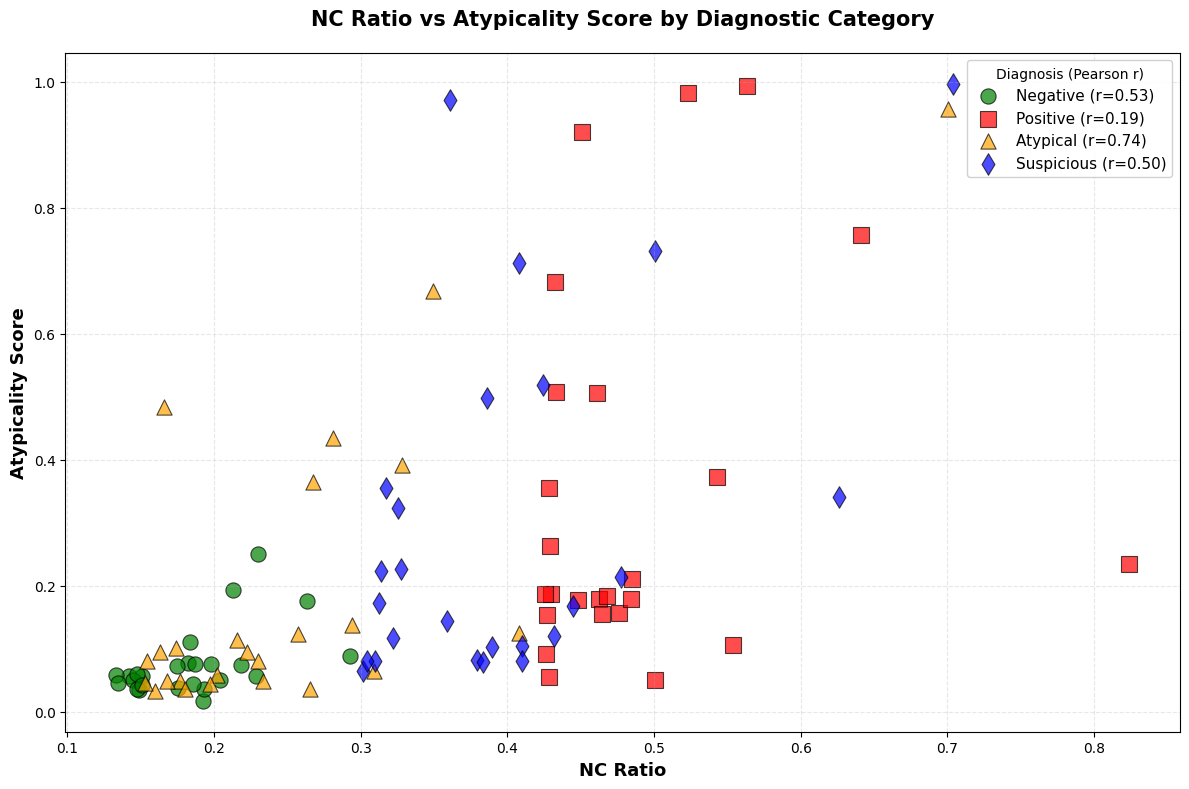

CORRELATION BY DIAGNOSTIC CATEGORY
Negative    : r=+0.533, p=0.0061
Positive    : r=+0.185, p=0.3755
Atypical    : r=+0.742, p=0.0000
Suspicious  : r=+0.500, p=0.0109


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load data
data = pd.read_pickle('specimens_toy_data.pkl')

all_metadata = []
all_labels = []

for category in ['neg', 'pos', 'aty', 'sus']:
    all_metadata.append(data[category]['metadata'])
    all_labels.extend([category] * len(data[category]['metadata']))

df = pd.concat(all_metadata, ignore_index=True)
df['target'] = all_labels

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

colors = {'neg': 'green', 'pos': 'red', 'aty': 'orange', 'sus': 'blue'}
markers = {'neg': 'o', 'pos': 's', 'aty': '^', 'sus': 'd'}
labels = {'neg': 'Negative', 'pos': 'Positive', 'aty': 'Atypical', 'sus': 'Suspicious'}

# Plot each category
for category in ['neg', 'pos', 'aty', 'sus']:
    mask = df['target'] == category
    data_subset = df[mask]

    # Calculate correlation for this category
    if len(data_subset) > 2:
        corr, p_val = pearsonr(data_subset['nc_ratio'], data_subset['aty'])
        label_text = f"{labels[category]} (r={corr:.2f})"
    else:
        label_text = labels[category]

    ax.scatter(data_subset['nc_ratio'],
              data_subset['aty'],
              c=colors[category],
              marker=markers[category],
              label=label_text,
              alpha=0.7,
              s=120,
              edgecolors='black',
              linewidth=0.8)

ax.set_xlabel('NC Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Atypicality Score', fontsize=13, fontweight='bold')
ax.set_title('NC Ratio vs Atypicality Score by Diagnostic Category',
            fontsize=15, fontweight='bold', pad=20)
ax.legend(title='Diagnosis (Pearson r)', fontsize=11, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('nc_ratio_vs_aty_enhanced.png', dpi=150)
plt.show()

# Print statistics
print("="*60)
print("CORRELATION BY DIAGNOSTIC CATEGORY")
print("="*60)
for category in ['neg', 'pos', 'aty', 'sus']:
    mask = df['target'] == category
    data_subset = df[mask]
    corr, p_val = pearsonr(data_subset['nc_ratio'], data_subset['aty'])
    print(f"{labels[category]:12s}: r={corr:+.3f}, p={p_val:.4f}")

neg : r = +0.533, R² = 0.284, p = 0.0061
pos : r = +0.185, R² = 0.034, p = 0.3755
aty : r = +0.742, R² = 0.550, p = 0.0000
sus : r = +0.500, R² = 0.250, p = 0.0109


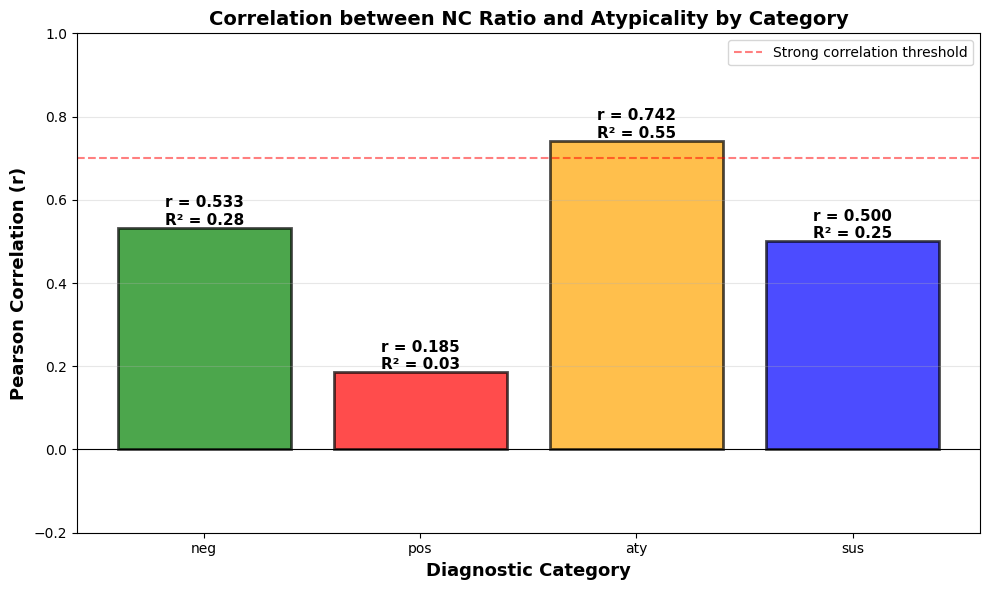

In [24]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load data
data = pd.read_pickle('specimens_toy_data.pkl')

all_metadata = []
all_labels = []

for category in ['neg', 'pos', 'aty', 'sus']:
    all_metadata.append(data[category]['metadata'])
    all_labels.extend([category] * len(data[category]['metadata']))

df = pd.concat(all_metadata, ignore_index=True)
df['target'] = all_labels

# Calculate correlation for each category
correlations = []
labels_list = []

for category in ['neg', 'pos', 'aty', 'sus']:
    mask = df['target'] == category
    data_subset = df[mask]

    r, p = pearsonr(data_subset['nc_ratio'], data_subset['aty'])
    correlations.append(r)
    labels_list.append(category)

    print(f"{category:4s}: r = {r:+.3f}, R² = {r**2:.3f}, p = {p:.4f}")

# Visualize comparison
plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'orange', 'blue']
bars = plt.bar(labels_list, correlations, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, corr in zip(bars, correlations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'r = {corr:.3f}\nR² = {corr**2:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Diagnostic Category', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation (r)', fontsize=13, fontweight='bold')
plt.title('Correlation between NC Ratio and Atypicality by Category', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(y=0.7, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Strong correlation threshold')
plt.ylim(-0.2, 1.0)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=150)
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Load data
data = pd.read_pickle('specimens_toy_data.pkl')

# Extract only Negative and Positive
neg_data = data['neg']['metadata'].copy()
neg_data['target'] = 0  # Negative = 0

pos_data = data['pos']['metadata'].copy()
pos_data['target'] = 1  # Positive = 1

# Combine
df = pd.concat([neg_data, pos_data], ignore_index=True)

print("="*60)
print("BINARY CLASSIFICATION: NEGATIVE vs. POSITIVE")
print("="*60)
print(f"Total samples: {len(df)}")
print(f"  Negative (0): {sum(df['target'] == 0)}")
print(f"  Positive (1): {sum(df['target'] == 1)}")

# Features and target
X = df[['nc_ratio']].values  # Only nc_ratio!
y = df['target'].values

print(f"\nFeature (X): nc_ratio only")
print(f"  Shape: {X.shape}")
print(f"  Range: [{X.min():.3f}, {X.max():.3f}]")

BINARY CLASSIFICATION: NEGATIVE vs. POSITIVE
Total samples: 50
  Negative (0): 25
  Positive (1): 25

Feature (X): nc_ratio only
  Shape: (50, 1)
  Range: [0.133, 0.824]


#Classifying Neg vs. Pos using NC_ratio

/tmp/ipython-input-383158010.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=['Negative', 'Positive'], patch_artist=True)


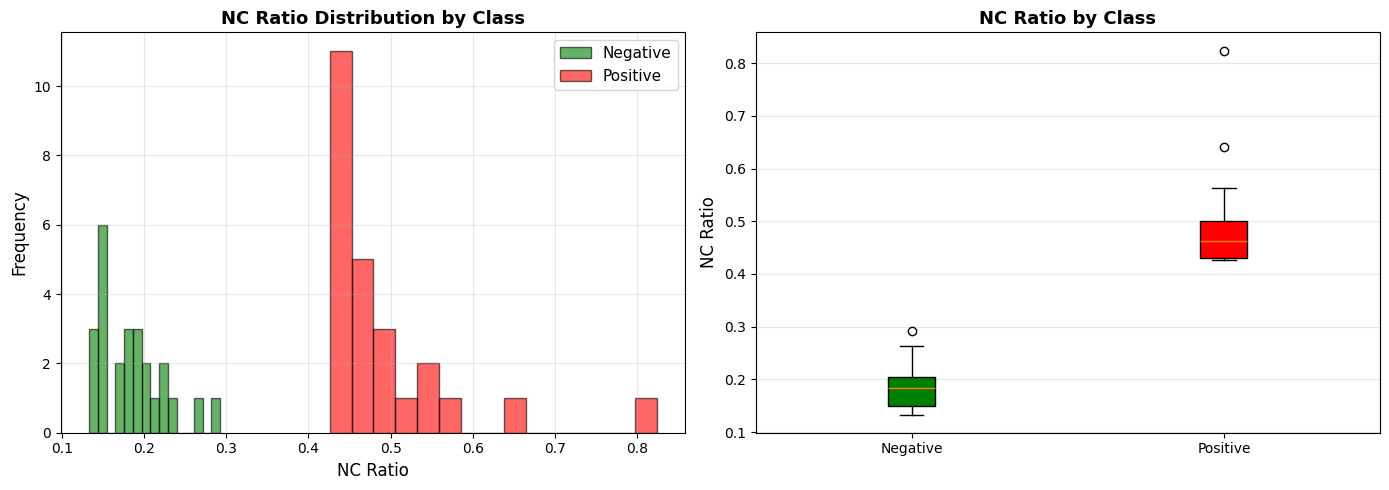


NC RATIO STATISTICS BY CLASS
Negative: mean=0.185, std=0.041
Positive: mean=0.488, std=0.088


In [26]:
# See how nc_ratio differs between negative and positive
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histograms
axes[0].hist(df[df['target'] == 0]['nc_ratio'], bins=15, alpha=0.6,
            color='green', label='Negative', edgecolor='black')
axes[0].hist(df[df['target'] == 1]['nc_ratio'], bins=15, alpha=0.6,
            color='red', label='Positive', edgecolor='black')
axes[0].set_xlabel('NC Ratio', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('NC Ratio Distribution by Class', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Box plots
bp_data = [df[df['target'] == 0]['nc_ratio'], df[df['target'] == 1]['nc_ratio']]
bp = axes[1].boxplot(bp_data, labels=['Negative', 'Positive'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
axes[1].set_ylabel('NC Ratio', fontsize=12)
axes[1].set_title('NC Ratio by Class', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('nc_ratio_distributions.png', dpi=150)
plt.show()

# Statistics
print("\n" + "="*60)
print("NC RATIO STATISTICS BY CLASS")
print("="*60)
print(f"Negative: mean={df[df['target']==0]['nc_ratio'].mean():.3f}, "
      f"std={df[df['target']==0]['nc_ratio'].std():.3f}")
print(f"Positive: mean={df[df['target']==1]['nc_ratio'].mean():.3f}, "
      f"std={df[df['target']==1]['nc_ratio'].std():.3f}")

BINARY CLASSIFICATION: NEGATIVE vs POSITIVE
Using only NC_RATIO as feature
Total samples: 50
  Negative: 25
  Positive: 25

Training: 40, Test: 10

RESULTS
Accuracy: 1.000 (100.0%)
AUC-ROC:  1.000

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         5
    Positive       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



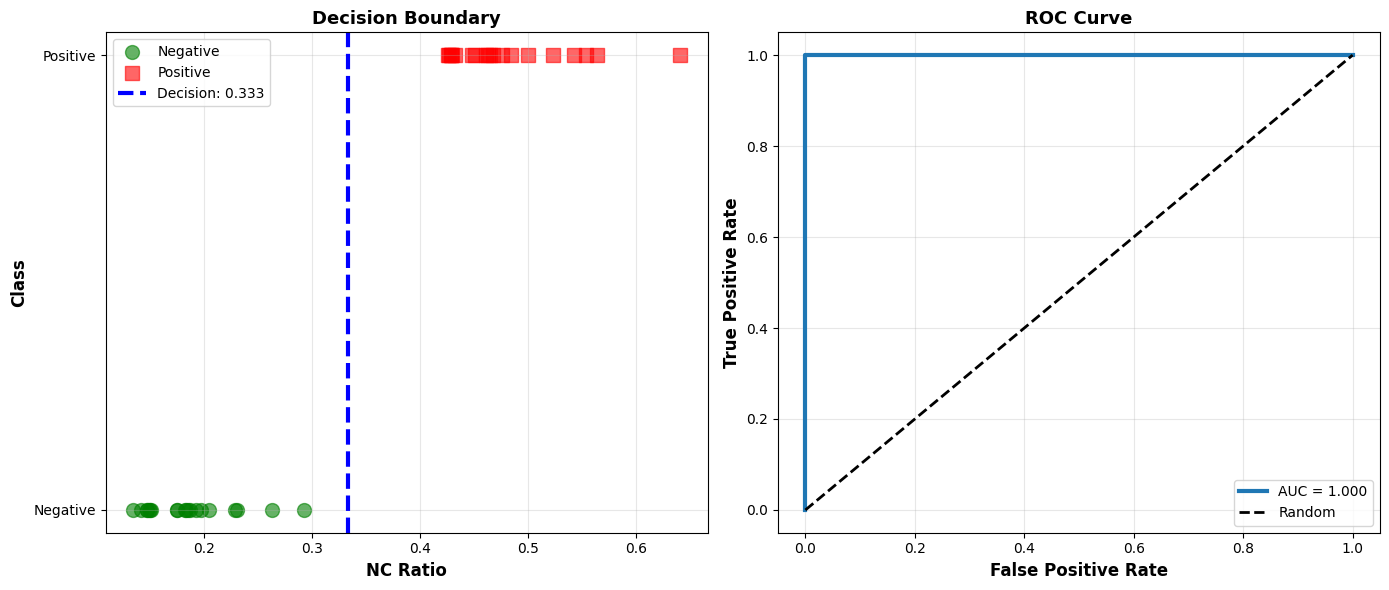


Decision Rule:
  nc_ratio < 0.333 → NEGATIVE
  nc_ratio ≥ 0.333 → POSITIVE


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_pickle('specimens_toy_data.pkl')

neg_data = data['neg']['metadata'].copy()
neg_data['target'] = 0

pos_data = data['pos']['metadata'].copy()
pos_data['target'] = 1

df = pd.concat([neg_data, pos_data], ignore_index=True)

X = df[['nc_ratio']].values
y = df['target'].values

print("="*60)
print("BINARY CLASSIFICATION: NEGATIVE vs POSITIVE")
print("Using only NC_RATIO as feature")
print("="*60)
print(f"Total samples: {len(df)}")
print(f"  Negative: {sum(y == 0)}")
print(f"  Positive: {sum(y == 1)}")

# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining: {len(X_train)}, Test: {len(X_test)}")

# ============================================================
# TRAIN MODEL
# ============================================================

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

# ============================================================
# EVALUATE
# ============================================================

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"AUC-ROC:  {auc:.3f}")

print("\n" + classification_report(y_test, y_pred,
                                  target_names=['Negative', 'Positive']))

# ============================================================
# VISUALIZE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Decision boundary
ax = axes[0]
neg_train = X_train[y_train == 0]
pos_train = X_train[y_train == 1]

ax.scatter(neg_train, np.zeros_like(neg_train),
          c='green', alpha=0.6, s=100, label='Negative', marker='o')
ax.scatter(pos_train, np.ones_like(pos_train),
          c='red', alpha=0.6, s=100, label='Positive', marker='s')

decision_boundary = -clf.intercept_[0] / clf.coef_[0][0]
ax.axvline(decision_boundary, color='blue', linestyle='--', linewidth=3,
          label=f'Decision: {decision_boundary:.3f}')

ax.set_xlabel('NC Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Class', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary', fontsize=13, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Negative', 'Positive'])
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, linewidth=3, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('binary_classification_results.png', dpi=150)
plt.show()

print(f"\nDecision Rule:")
print(f"  nc_ratio < {decision_boundary:.3f} → NEGATIVE")
print(f"  nc_ratio ≥ {decision_boundary:.3f} → POSITIVE")

#Classifying Negative + Atypical vs. Positive + Suspect using NC_ratio

BINARY CLASSIFICATION WITH GROUPED CATEGORIES
Group 0 (neg+aty): 50 samples
  - neg: 25
  - aty: 25

Group 1 (pos+sus): 50 samples
  - pos: 25
  - sus: 25

Feature: nc_ratio only
  Group 0 mean: 0.218 ± 0.091
  Group 1 mean: 0.443 ± 0.102
  Difference:   0.225

TRAIN-TEST SPLIT
Training: 80 samples
  Group 0: 40 (neg=19, aty=21)
  Group 1: 40 (pos=19, sus=21)

Test: 20 samples
  Group 0: 10
  Group 1: 10

LOGISTIC REGRESSION MODEL
Coefficient: 3.0142
Intercept:   -0.9888

Decision boundary: nc_ratio = 0.328
  If nc_ratio < 0.328 → Group 0 (neg+aty)
  If nc_ratio ≥ 0.328 → Group 1 (pos+sus)

MODEL PERFORMANCE
Accuracy: 0.900 (90.0%)
AUC-ROC:  1.000

Classification Report:
                   precision    recall  f1-score   support

Group 0 (neg+aty)      0.833     1.000     0.909        10
Group 1 (pos+sus)      1.000     0.800     0.889        10

         accuracy                          0.900        20
        macro avg      0.917     0.900     0.899        20
     weighted avg      

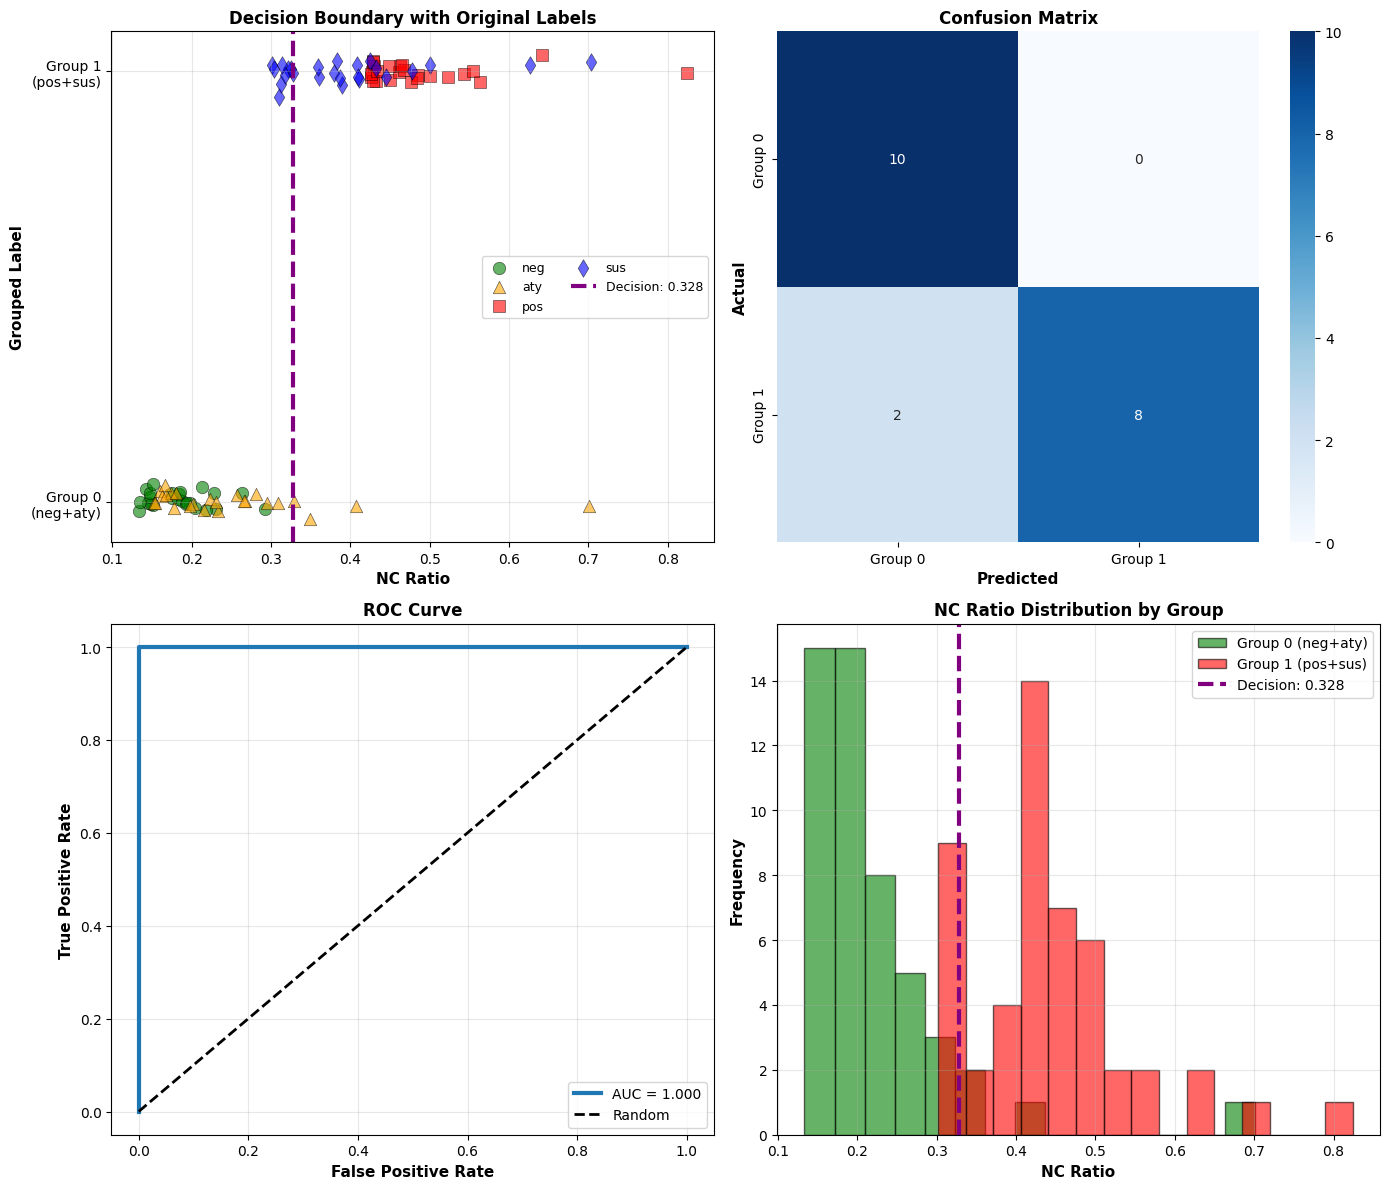

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# ============================================================
# STEP 1: LOAD AND GROUP DATA
# ============================================================

data = pd.read_pickle('specimens_toy_data.pkl')

# Create grouped dataset
group0_data = []  # neg + aty
group1_data = []  # pos + sus

# Group 0: neg + aty
for category in ['neg', 'aty']:
    df_cat = data[category]['metadata'].copy()
    df_cat['original_label'] = category
    df_cat['grouped_label'] = 0  # Group 0
    group0_data.append(df_cat)

# Group 1: pos + sus
for category in ['pos', 'sus']:
    df_cat = data[category]['metadata'].copy()
    df_cat['original_label'] = category
    df_cat['grouped_label'] = 1  # Group 1
    group1_data.append(df_cat)

# Combine
df = pd.concat(group0_data + group1_data, ignore_index=True)

print("="*60)
print("BINARY CLASSIFICATION WITH GROUPED CATEGORIES")
print("="*60)
print(f"Group 0 (neg+aty): {sum(df['grouped_label'] == 0)} samples")
print(f"  - neg: {sum(df['original_label'] == 'neg')}")
print(f"  - aty: {sum(df['original_label'] == 'aty')}")
print(f"\nGroup 1 (pos+sus): {sum(df['grouped_label'] == 1)} samples")
print(f"  - pos: {sum(df['original_label'] == 'pos')}")
print(f"  - sus: {sum(df['original_label'] == 'sus')}")

# ============================================================
# STEP 2: PREPARE FEATURES AND TARGET
# ============================================================

X = df[['nc_ratio']].values
y = df['grouped_label'].values

print(f"\nFeature: nc_ratio only")
print(f"  Group 0 mean: {X[y == 0].mean():.3f} ± {X[y == 0].std():.3f}")
print(f"  Group 1 mean: {X[y == 1].mean():.3f} ± {X[y == 1].std():.3f}")
print(f"  Difference:   {X[y == 1].mean() - X[y == 0].mean():.3f}")

# ============================================================
# STEP 3: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Also keep track of original labels for analysis
df_train = df.iloc[train_test_split(range(len(df)), test_size=0.2,
                                     random_state=42, stratify=y)[0]]
df_test = df.iloc[train_test_split(range(len(df)), test_size=0.2,
                                    random_state=42, stratify=y)[1]]

print(f"\n{'='*60}")
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training: {len(X_train)} samples")
print(f"  Group 0: {sum(y_train == 0)} (neg={sum(df_train['original_label']=='neg')}, "
      f"aty={sum(df_train['original_label']=='aty')})")
print(f"  Group 1: {sum(y_train == 1)} (pos={sum(df_train['original_label']=='pos')}, "
      f"sus={sum(df_train['original_label']=='sus')})")

print(f"\nTest: {len(X_test)} samples")
print(f"  Group 0: {sum(y_test == 0)}")
print(f"  Group 1: {sum(y_test == 1)}")

# ============================================================
# STEP 4: TRAIN LOGISTIC REGRESSION
# ============================================================

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

print(f"\n{'='*60}")
print("LOGISTIC REGRESSION MODEL")
print("="*60)
print(f"Coefficient: {clf.coef_[0][0]:.4f}")
print(f"Intercept:   {clf.intercept_[0]:.4f}")

decision_boundary = -clf.intercept_[0] / clf.coef_[0][0]
print(f"\nDecision boundary: nc_ratio = {decision_boundary:.3f}")
print(f"  If nc_ratio < {decision_boundary:.3f} → Group 0 (neg+aty)")
print(f"  If nc_ratio ≥ {decision_boundary:.3f} → Group 1 (pos+sus)")

# ============================================================
# STEP 5: EVALUATE
# ============================================================

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"AUC-ROC:  {auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Group 0 (neg+aty)', 'Group 1 (pos+sus)'],
                          digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                    Predicted")
print(f"                    Group 0   Group 1")
print(f"Actual  Group 0     {cm[0,0]:5d}     {cm[0,1]:5d}")
print(f"        Group 1     {cm[1,0]:5d}     {cm[1,1]:5d}")

# ============================================================
# STEP 6: ANALYZE BY ORIGINAL LABELS
# ============================================================

print(f"\n{'='*60}")
print("PERFORMANCE BY ORIGINAL CATEGORY")
print("="*60)

# Create predictions with original labels
df_test_copy = df_test.copy()
df_test_copy['predicted_group'] = y_pred

for orig_cat in ['neg', 'aty', 'pos', 'sus']:
    mask = df_test_copy['original_label'] == orig_cat
    if mask.sum() > 0:
        correct = (df_test_copy[mask]['grouped_label'] ==
                   df_test_copy[mask]['predicted_group']).sum()
        total = mask.sum()
        acc = correct / total
        print(f"{orig_cat:4s}: {correct}/{total} correct ({acc*100:.1f}%)")

# ============================================================
# STEP 7: VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Decision boundary with original labels
ax = axes[0, 0]

colors_orig = {'neg': 'green', 'aty': 'orange', 'sus': 'blue', 'pos': 'red'}
markers_orig = {'neg': 'o', 'aty': '^', 'sus': 'd', 'pos': 's'}

for orig_cat in ['neg', 'aty', 'pos', 'sus']:
    mask = df['original_label'] == orig_cat
    group_val = df[mask]['grouped_label'].iloc[0]

    ax.scatter(df[mask]['nc_ratio'],
              np.full(mask.sum(), group_val) + np.random.normal(0, 0.02, mask.sum()),
              c=colors_orig[orig_cat], marker=markers_orig[orig_cat],
              alpha=0.6, s=80, label=orig_cat, edgecolors='black', linewidths=0.5)

ax.axvline(decision_boundary, color='purple', linestyle='--', linewidth=3,
          label=f'Decision: {decision_boundary:.3f}')
ax.set_xlabel('NC Ratio', fontsize=11, fontweight='bold')
ax.set_ylabel('Grouped Label', fontsize=11, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Group 0\n(neg+aty)', 'Group 1\n(pos+sus)'])
ax.set_title('Decision Boundary with Original Labels', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)

# Plot 2: Confusion matrix heatmap
ax = axes[0, 1]
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
           xticklabels=['Group 0', 'Group 1'],
           yticklabels=['Group 0', 'Group 1'])
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 3: ROC Curve
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, linewidth=3, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Plot 4: Distribution comparison
ax = axes[1, 1]
ax.hist(X[y == 0], bins=15, alpha=0.6, color='green',
       label='Group 0 (neg+aty)', edgecolor='black')
ax.hist(X[y == 1], bins=15, alpha=0.6, color='red',
       label='Group 1 (pos+sus)', edgecolor='black')
ax.axvline(decision_boundary, color='purple', linestyle='--', linewidth=3,
          label=f'Decision: {decision_boundary:.3f}')
ax.set_xlabel('NC Ratio', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('NC Ratio Distribution by Group', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grouped_classification_results.png', dpi=150)
plt.show()

#Polynomial Regression Between NC_ratio, and Aty_score among atypical cases

POLYNOMIAL REGRESSION: NC_RATIO vs ATY (ATYPICAL CASES ONLY)
Number of atypical cases: 25

NC Ratio statistics:
  Mean: 0.250
  Std:  0.116
  Range: [0.153, 0.701]

Aty Score statistics:
  Mean: 0.188
  Std:  0.233
  Range: [0.033, 0.956]

Data split:
  Training: 20 samples
  Test: 5 samples

FITTING POLYNOMIAL MODELS

Degree 1:
  Train R²: 0.5572  |  Test R²: 0.4580
  Train MSE: 0.0219  |  Test MSE: 0.0328

Degree 2:
  Train R²: 0.6571  |  Test R²: 0.0649
  Train MSE: 0.0170  |  Test MSE: 0.0566

Degree 3:
  Train R²: 0.6599  |  Test R²: 0.0435
  Train MSE: 0.0168  |  Test MSE: 0.0579

Degree 4:
  Train R²: 0.7001  |  Test R²: 0.2225
  Train MSE: 0.0148  |  Test MSE: 0.0471

Degree 5:
  Train R²: 0.7141  |  Test R²: 0.4032
  Train MSE: 0.0141  |  Test MSE: 0.0361

BEST MODEL: Degree 1
  Test R²: 0.4580
  Test MSE: 0.0328


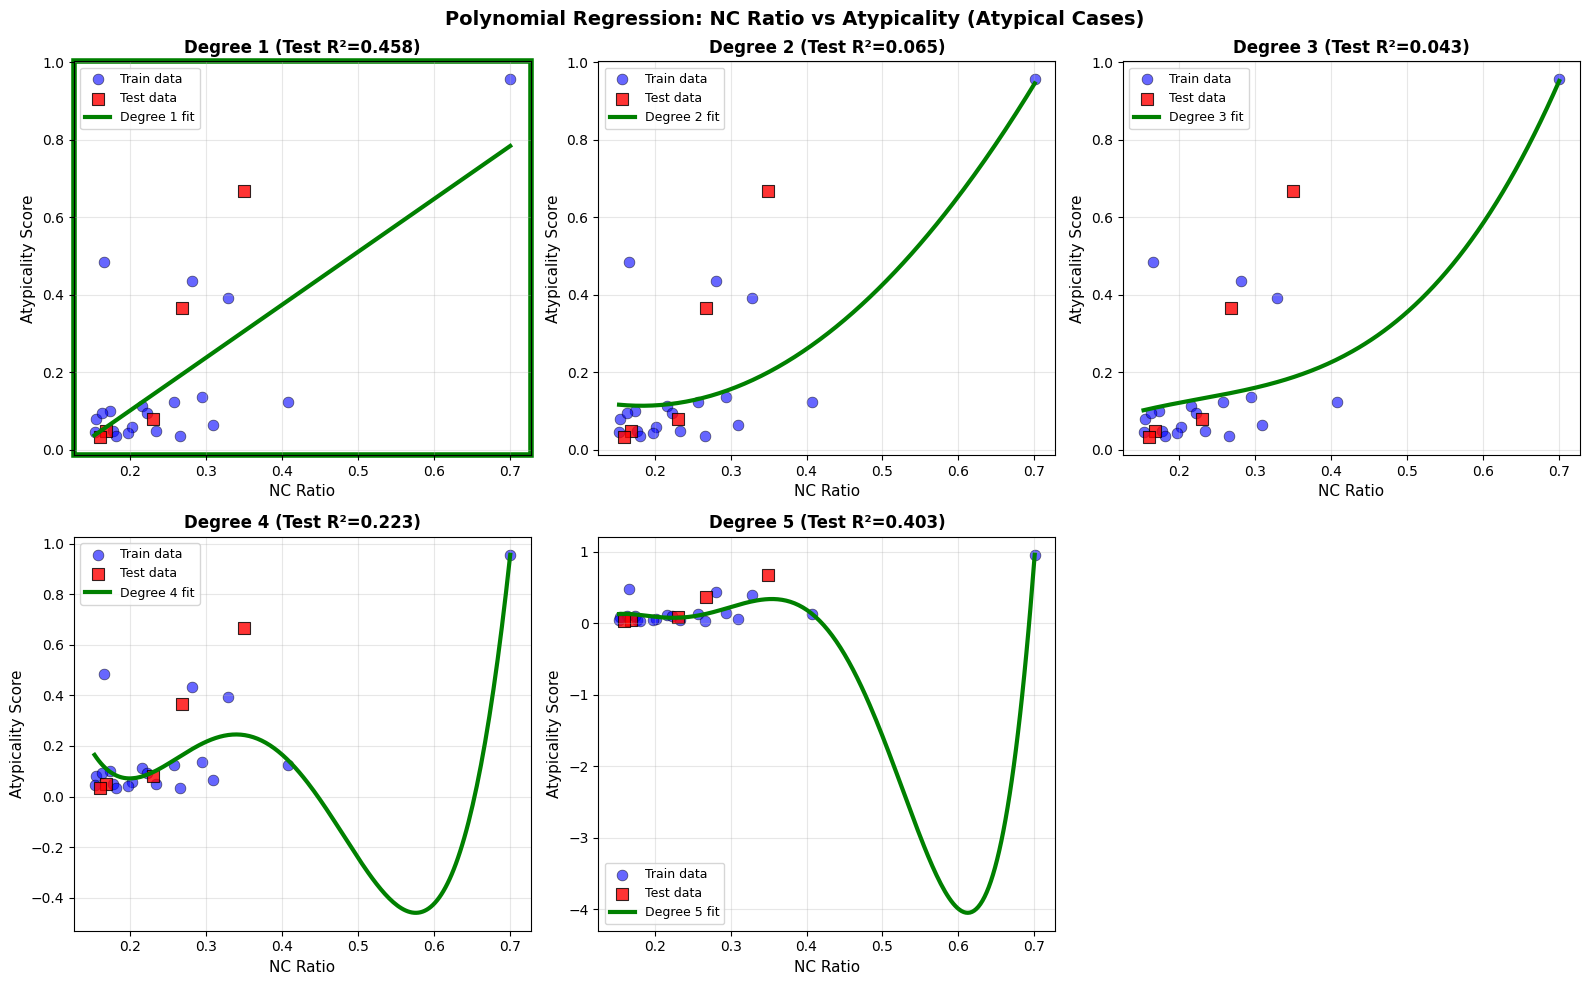

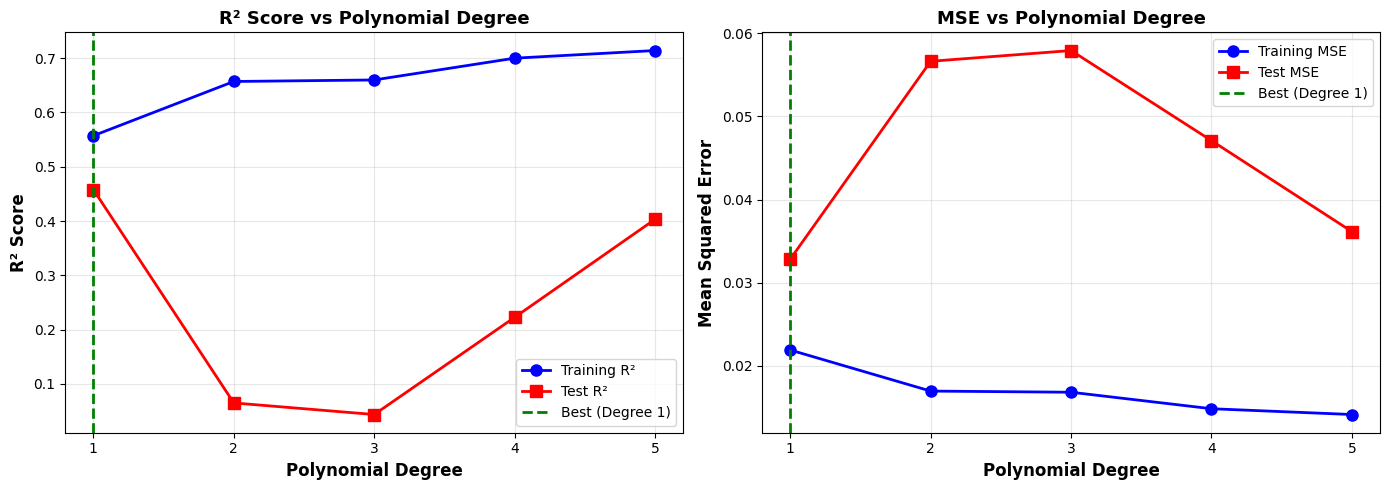


DETAILED ANALYSIS: DEGREE 1 POLYNOMIAL

Polynomial equation:
  aty = -0.1705 + 1.3627 × nc_ratio^1

Residual analysis:
  Mean residual: 0.017861 (should be ~0)
  Std of residuals: 0.1542
  Max positive residual: 0.4281
  Max negative residual: -0.2604


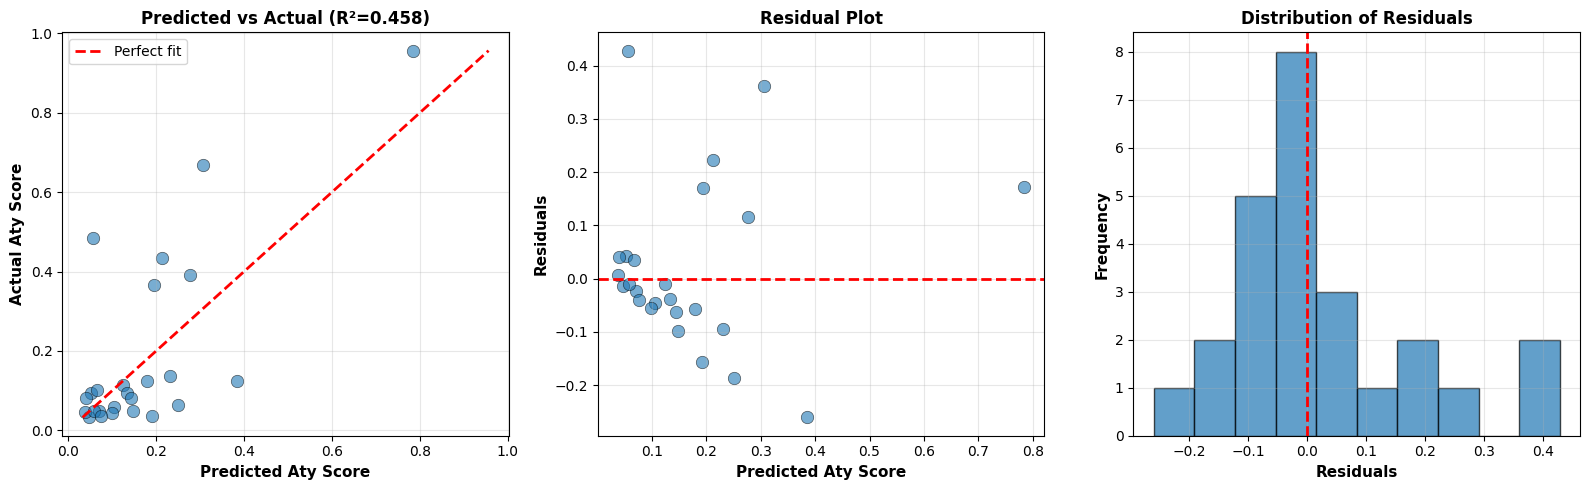


EXAMPLE PREDICTIONS

NC Ratio: 0.250
  Predicted Aty Score: 0.170

NC Ratio: 0.300
  Predicted Aty Score: 0.238

NC Ratio: 0.350
  Predicted Aty Score: 0.306

NC Ratio: 0.400
  Predicted Aty Score: 0.375

NC Ratio: 0.450
  Predicted Aty Score: 0.443

SUMMARY TABLE: ALL POLYNOMIAL MODELS
Degree   Train R²     Test R²      Train MSE    Test MSE    
------------------------------------------------------------
1        0.5572       0.4580       0.0219       0.0328       ← BEST
2        0.6571       0.0649       0.0170       0.0566      
3        0.6599       0.0435       0.0168       0.0579      
4        0.7001       0.2225       0.0148       0.0471      
5        0.7141       0.4032       0.0141       0.0361      


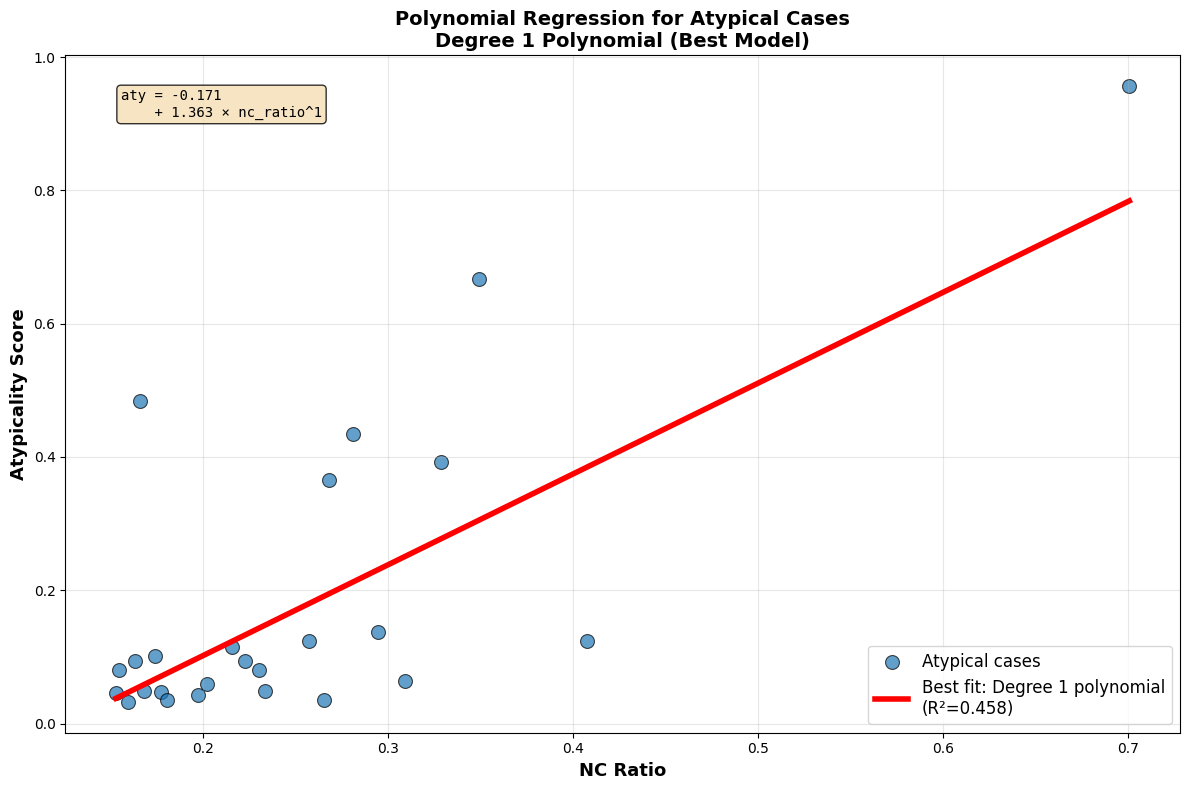


ANALYSIS COMPLETE!


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# ============================================================
# STEP 1: LOAD ATYPICAL DATA ONLY
# ============================================================

data = pd.read_pickle('specimens_toy_data.pkl')

# Extract only atypical cases
aty_data = data['aty']['metadata'].copy()

print("="*60)
print("POLYNOMIAL REGRESSION: NC_RATIO vs ATY (ATYPICAL CASES ONLY)")
print("="*60)
print(f"Number of atypical cases: {len(aty_data)}")
print(f"\nNC Ratio statistics:")
print(f"  Mean: {aty_data['nc_ratio'].mean():.3f}")
print(f"  Std:  {aty_data['nc_ratio'].std():.3f}")
print(f"  Range: [{aty_data['nc_ratio'].min():.3f}, {aty_data['nc_ratio'].max():.3f}]")

print(f"\nAty Score statistics:")
print(f"  Mean: {aty_data['aty'].mean():.3f}")
print(f"  Std:  {aty_data['aty'].std():.3f}")
print(f"  Range: [{aty_data['aty'].min():.3f}, {aty_data['aty'].max():.3f}]")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

X = aty_data['nc_ratio'].values.reshape(-1, 1)
y = aty_data['aty'].values

# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nData split:")
print(f"  Training: {len(X_train)} samples")
print(f"  Test: {len(X_test)} samples")

# ============================================================
# STEP 3: FIT POLYNOMIAL MODELS (Degrees 1-5)
# ============================================================

print(f"\n{'='*60}")
print("FITTING POLYNOMIAL MODELS")
print("="*60)

degrees = range(1, 6)  # Try polynomials of degree 1 through 5
results = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit linear regression on polynomial features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    results.append({
        'degree': degree,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'model': model,
        'poly': poly
    })

    print(f"\nDegree {degree}:")
    print(f"  Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
    print(f"  Train MSE: {train_mse:.4f}  |  Test MSE: {test_mse:.4f}")

# Find best model based on test R²
best_result = max(results, key=lambda x: x['test_r2'])
best_degree = best_result['degree']

print(f"\n{'='*60}")
print(f"BEST MODEL: Degree {best_degree}")
print(f"  Test R²: {best_result['test_r2']:.4f}")
print(f"  Test MSE: {best_result['test_mse']:.4f}")
print("="*60)

# ============================================================
# STEP 4: VISUALIZE ALL POLYNOMIAL FITS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, result in enumerate(results):
    degree = result['degree']
    model = result['model']
    poly = result['poly']

    ax = axes[i]

    # Scatter plot of actual data
    ax.scatter(X_train, y_train, alpha=0.6, s=60,
              label='Train data', color='blue', edgecolors='black', linewidths=0.5)
    ax.scatter(X_test, y_test, alpha=0.8, s=80,
              label='Test data', color='red', marker='s', edgecolors='black', linewidths=0.8)

    # Generate smooth curve for visualization
    X_smooth = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    X_smooth_poly = poly.transform(X_smooth)
    y_smooth_pred = model.predict(X_smooth_poly)

    ax.plot(X_smooth, y_smooth_pred, 'g-', linewidth=3,
           label=f'Degree {degree} fit')

    ax.set_xlabel('NC Ratio', fontsize=11)
    ax.set_ylabel('Atypicality Score', fontsize=11)
    ax.set_title(f'Degree {degree} (Test R²={result["test_r2"]:.3f})',
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Highlight best model
    if degree == best_degree:
        ax.patch.set_edgecolor('green')
        ax.patch.set_linewidth(4)

# Hide the 6th subplot (we only have 5 models)
axes[5].axis('off')

plt.suptitle('Polynomial Regression: NC Ratio vs Atypicality (Atypical Cases)',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('polynomial_regression_atypical.png', dpi=150)
plt.show()

# ============================================================
# STEP 5: COMPARE METRICS ACROSS DEGREES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² scores
ax = axes[0]
train_r2_vals = [r['train_r2'] for r in results]
test_r2_vals = [r['test_r2'] for r in results]
degrees_list = [r['degree'] for r in results]

ax.plot(degrees_list, train_r2_vals, 'o-', linewidth=2, markersize=8,
       label='Training R²', color='blue')
ax.plot(degrees_list, test_r2_vals, 's-', linewidth=2, markersize=8,
       label='Test R²', color='red')
ax.axvline(best_degree, color='green', linestyle='--', linewidth=2,
          label=f'Best (Degree {best_degree})')
ax.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² Score vs Polynomial Degree', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(degrees_list)

# Plot 2: MSE
ax = axes[1]
train_mse_vals = [r['train_mse'] for r in results]
test_mse_vals = [r['test_mse'] for r in results]

ax.plot(degrees_list, train_mse_vals, 'o-', linewidth=2, markersize=8,
       label='Training MSE', color='blue')
ax.plot(degrees_list, test_mse_vals, 's-', linewidth=2, markersize=8,
       label='Test MSE', color='red')
ax.axvline(best_degree, color='green', linestyle='--', linewidth=2,
          label=f'Best (Degree {best_degree})')
ax.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax.set_title('MSE vs Polynomial Degree', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks(degrees_list)

plt.tight_layout()
plt.savefig('polynomial_metrics_comparison.png', dpi=150)
plt.show()

# ============================================================
# STEP 6: DETAILED ANALYSIS OF BEST MODEL
# ============================================================

print(f"\n{'='*60}")
print(f"DETAILED ANALYSIS: DEGREE {best_degree} POLYNOMIAL")
print("="*60)

best_model = best_result['model']
best_poly = best_result['poly']

# Get coefficients
coefficients = best_model.coef_
intercept = best_model.intercept_

print(f"\nPolynomial equation:")
print(f"  aty = {intercept:.4f}", end="")
for i, coef in enumerate(coefficients[1:], start=1):  # Skip intercept term
    if coef >= 0:
        print(f" + {coef:.4f} × nc_ratio^{i}", end="")
    else:
        print(f" - {abs(coef):.4f} × nc_ratio^{i}", end="")
print()

# Make predictions on all data for visualization
X_all_poly = best_poly.transform(X)
y_pred_all = best_model.predict(X_all_poly)

# Calculate residuals
residuals = y - y_pred_all

print(f"\nResidual analysis:")
print(f"  Mean residual: {residuals.mean():.6f} (should be ~0)")
print(f"  Std of residuals: {residuals.std():.4f}")
print(f"  Max positive residual: {residuals.max():.4f}")
print(f"  Max negative residual: {residuals.min():.4f}")

# ============================================================
# STEP 7: RESIDUAL PLOTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Fitted values vs actual
ax = axes[0]
ax.scatter(y_pred_all, y, alpha=0.6, s=80, edgecolors='black', linewidths=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2,
       label='Perfect fit')
ax.set_xlabel('Predicted Aty Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Aty Score', fontsize=11, fontweight='bold')
ax.set_title(f'Predicted vs Actual (R²={best_result["test_r2"]:.3f})',
            fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Residuals vs fitted values
ax = axes[1]
ax.scatter(y_pred_all, residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Aty Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 3: Histogram of residuals
ax = axes[2]
ax.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150)
plt.show()

# ============================================================
# STEP 8: PREDICTION FUNCTION
# ============================================================

def predict_aty_from_nc_ratio(nc_ratio_value):
    """Predict atypicality score from nc_ratio using best polynomial model"""
    X_new = np.array([[nc_ratio_value]])
    X_new_poly = best_poly.transform(X_new)
    aty_pred = best_model.predict(X_new_poly)[0]

    print(f"\nNC Ratio: {nc_ratio_value:.3f}")
    print(f"  Predicted Aty Score: {aty_pred:.3f}")

    return aty_pred

# Test predictions
print(f"\n{'='*60}")
print("EXAMPLE PREDICTIONS")
print("="*60)

test_nc_values = [0.25, 0.30, 0.35, 0.40, 0.45]
for nc_val in test_nc_values:
    predict_aty_from_nc_ratio(nc_val)

# ============================================================
# STEP 9: SUMMARY TABLE
# ============================================================

print(f"\n{'='*60}")
print("SUMMARY TABLE: ALL POLYNOMIAL MODELS")
print("="*60)
print(f"{'Degree':<8} {'Train R²':<12} {'Test R²':<12} {'Train MSE':<12} {'Test MSE':<12}")
print("-"*60)
for result in results:
    marker = " ← BEST" if result['degree'] == best_degree else ""
    print(f"{result['degree']:<8} {result['train_r2']:<12.4f} {result['test_r2']:<12.4f} "
          f"{result['train_mse']:<12.4f} {result['test_mse']:<12.4f}{marker}")

# ============================================================
# STEP 10: FINAL VISUALIZATION - BEST MODEL
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
ax.scatter(X, y, alpha=0.7, s=100, label='Atypical cases',
          edgecolors='black', linewidths=0.8)

# Fitted curve
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_smooth_poly = best_poly.transform(X_smooth)
y_smooth_pred = best_model.predict(X_smooth_poly)

ax.plot(X_smooth, y_smooth_pred, 'r-', linewidth=4,
       label=f'Best fit: Degree {best_degree} polynomial\n(R²={best_result["test_r2"]:.3f})')

ax.set_xlabel('NC Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Atypicality Score', fontsize=13, fontweight='bold')
ax.set_title(f'Polynomial Regression for Atypical Cases\n'
            f'Degree {best_degree} Polynomial (Best Model)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(alpha=0.3)

# Add text box with equation
equation_text = f"aty = {intercept:.3f}"
for i, coef in enumerate(coefficients[1:], start=1):
    if coef >= 0:
        equation_text += f"\n    + {coef:.3f} × nc_ratio^{i}"
    else:
        equation_text += f"\n    - {abs(coef):.3f} × nc_ratio^{i}"

ax.text(0.05, 0.95, equation_text,
       transform=ax.transAxes,
       fontsize=10,
       verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
       family='monospace')

plt.tight_layout()
plt.savefig('best_polynomial_fit.png', dpi=150)
plt.show()

print(f"\n{'='*60}")
print("ANALYSIS COMPLETE!")
print("="*60)